In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("../graphs and tables")
output_dir.mkdir(exist_ok=True)

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("UGov_Data.csv", low_memory=False)

print("Original shape:", df.shape)
display(df.head())

Original shape: (53833, 44)


,record_id,response_time,survey_week,age,gender,state,household_size,employment_status,survey_weight,wore_mask_outside_home,used_hand_sanitiser,covered_nose_mouth_when_sneezing_coughing,avoided_contact_with_symptomatic_people,avoided_going_out_in_general,avoided_going_to_healthcare_settings,avoided_public_transport,avoided_small_social_gatherings,avoided_medium_social_gatherings,avoided_large_social_gatherings,avoided_crowded_areas,avoided_going_to_shops,washed_hands_with_soap_water,avoided_having_guests_at_home,would_self_isolate_if_symptomatic,willingness_to_self_isolate_7days,physical_contact_outside_household_count,confidence_in_health_system_covid_response,life_satisfaction_ladder,government_handling_covid,week_num,wore_mask_outside_home_adherent,washed_hands_with_soap_water_adherent,used_hand_sanitiser_adherent,covered_nose_mouth_when_sneezing_coughing_adherent,avoided_contact_with_symptomatic_people_adherent,avoided_crowded_areas_adherent,avoided_public_transport_adherent,avoided_having_guests_at_home_adherent,avoided_small_social_gatherings_adherent,avoided_medium_social_gatherings_adherent,avoided_large_social_gatherings_adherent,avoided_going_out_in_general_adherent,avoided_going_to_shops_adherent,avoided_going_to_healthcare_settings_adherent
0,0,01-04-2020 16:12,week 1,44,Male,Queensland,2.0,Not working - looking for work,0.678531,2,4,5,5,5,5,5,5,5,5,5,4,5.0,5.0,1.0,5.0,1.0,NaN,NaN,NaN,1,0,1.0,1,1,1,1,1,1.0,1,1,1,1,1,1
1,1,01-04-2020 16:12,week 1,66,Male,Victoria,1.0,Retired,1.049460,1,4,5,5,3,5,5,4,4,5,4,2,5.0,4.0,1.0,5.0,6.0,NaN,NaN,NaN,1,0,1.0,1,1,1,1,1,1.0,1,1,1,0,0,1
2,2,01-04-2020 16:13,week 1,22,Male,Victoria,3.0,Working part time (8-34 hours a week),1.271203,5,5,5,5,3,3,5,5,5,5,5,4,5.0,5.0,1.0,5.0,0.0,NaN,NaN,NaN,1,1,1.0,1,1,1,1,1,1.0,1,1,1,0,1,0
3,3,01-04-2020 16:16,week 1,45,Male,New South Wales,3.0,Working full time (35 or more hours per week),0.936885,5,4,5,5,4,4,5,5,5,5,4,2,4.0,5.0,1.0,5.0,20.0,NaN,NaN,NaN,1,1,1.0,1,1,1,1,1,1.0,1,1,1,1,0,1
4,4,01-04-2020 16:21,week 1,42,Female,Victoria,3.0,Working part time (8-34 hours a week),0.762042,1,3,5,5,5,5,5,3,5,5,5,3,5.0,5.0,1.0,4.0,0.0,NaN,NaN,NaN,1,0,1.0,0,1,1,1,1,1.0,0,1,1,1,0,1


# EDA

In [4]:
# Create numeric survey week if needed

if "week_num" not in df.columns:
    df["week_num"] = (
        df["survey_week"]
        .astype(str)
        .str.extract(r"(\d+)")[0]
        .astype(int)
    )

print("Week range:", df["week_num"].min(), "to", df["week_num"].max())
print("Number of survey weeks:", df["week_num"].nunique())

display(df[["survey_week", "week_num"]].head())

Week range: 1 to 54
Number of survey weeks: 54


,survey_week,week_num
0,week 1,1
1,week 1,1
2,week 1,1
3,week 1,1
4,week 1,1


In [5]:
# Behaviour columns in wide format

low_cost = [
    "covered_nose_mouth_when_sneezing_coughing",
    "washed_hands_with_soap_water",
    "used_hand_sanitiser"
]

medium_cost = [
    "wore_mask_outside_home",
    "avoided_contact_with_symptomatic_people",
    "avoided_crowded_areas",
    "avoided_public_transport",
    "avoided_having_guests_at_home"
]

high_cost = [
    "avoided_small_social_gatherings",
    "avoided_medium_social_gatherings",
    "avoided_large_social_gatherings",
    "avoided_going_out_in_general",
    "avoided_going_to_shops",
    "avoided_going_to_healthcare_settings"
]

behaviour_cols = low_cost + medium_cost + high_cost

cost_group_map = {}

for col in low_cost:
    cost_group_map[col] = "Low"

for col in medium_cost:
    cost_group_map[col] = "Medium"

for col in high_cost:
    cost_group_map[col] = "High"

graph_names = {
    "covered_nose_mouth_when_sneezing_coughing": "Covered cough/sneeze",
    "washed_hands_with_soap_water": "Washed hands",
    "used_hand_sanitiser": "Used sanitiser",
    "wore_mask_outside_home": "Wore mask outside home",
    "avoided_contact_with_symptomatic_people": "Avoided symptomatic people",
    "avoided_crowded_areas": "Avoided crowded areas",
    "avoided_public_transport": "Avoided public transport",
    "avoided_having_guests_at_home": "Avoided guests at home",
    "avoided_small_social_gatherings": "Avoided small gatherings",
    "avoided_medium_social_gatherings": "Avoided medium gatherings",
    "avoided_large_social_gatherings": "Avoided large gatherings",
    "avoided_going_out_in_general": "Avoided going out",
    "avoided_going_to_shops": "Avoided shops",
    "avoided_going_to_healthcare_settings": "Avoided healthcare settings"
}

print("Number of behaviour variables:", len(behaviour_cols))
print("Low-cost behaviours:", len(low_cost))
print("Medium-cost behaviours:", len(medium_cost))
print("High-cost behaviours:", len(high_cost))

Number of behaviour variables: 14
Low-cost behaviours: 3
Medium-cost behaviours: 5
High-cost behaviours: 6


In [6]:
# Collect the binary adherence columns created during data cleaning

binary_cols = [col + "_adherent" for col in behaviour_cols]

missing_binary_cols = [col for col in binary_cols if col not in df.columns]

print("Binary adherence columns expected:", len(binary_cols))
print("Missing binary adherence columns:", len(missing_binary_cols))

display(df[binary_cols].head())

Binary adherence columns expected: 14
Missing binary adherence columns: 0


,covered_nose_mouth_when_sneezing_coughing_adherent,washed_hands_with_soap_water_adherent,used_hand_sanitiser_adherent,wore_mask_outside_home_adherent,avoided_contact_with_symptomatic_people_adherent,avoided_crowded_areas_adherent,avoided_public_transport_adherent,avoided_having_guests_at_home_adherent,avoided_small_social_gatherings_adherent,avoided_medium_social_gatherings_adherent,avoided_large_social_gatherings_adherent,avoided_going_out_in_general_adherent,avoided_going_to_shops_adherent,avoided_going_to_healthcare_settings_adherent
0,1,1.0,1,0,1,1,1,1.0,1,1,1,1,1,1
1,1,1.0,1,0,1,1,1,1.0,1,1,1,0,0,1
2,1,1.0,1,1,1,1,1,1.0,1,1,1,0,1,0
3,1,1.0,1,1,1,1,1,1.0,1,1,1,1,0,1
4,1,1.0,0,0,1,1,1,1.0,0,1,1,1,0,1


In [7]:
missing_summary = pd.DataFrame({
    "behaviour": behaviour_cols,
    "cost_group": [cost_group_map[col] for col in behaviour_cols],
    "score_missing": [df[col].isna().sum() for col in behaviour_cols],
    "binary_missing": [df[col + "_adherent"].isna().sum() for col in behaviour_cols]
})

missing_summary["behaviour_label"] = missing_summary["behaviour"].map(graph_names)

display(missing_summary[["behaviour_label", "cost_group", "score_missing", "binary_missing"]])

,behaviour_label,cost_group,score_missing,binary_missing
0,Covered cough/sneeze,Low,0,0
1,Washed hands,Low,1006,1006
2,Used sanitiser,Low,0,0
3,Wore mask outside home,Medium,0,0
4,Avoided symptomatic people,Medium,0,0
5,Avoided crowded areas,Medium,0,0
6,Avoided public transport,Medium,0,0
7,Avoided guests at home,Medium,1006,1006
8,Avoided small gatherings,High,0,0
9,Avoided medium gatherings,High,0,0


In [8]:
# Weighted mean helper
# Uses survey_weight if available

weight_col = "survey_weight"

def weighted_mean(values, weights):
    values = pd.to_numeric(values, errors="coerce")
    weights = pd.to_numeric(weights, errors="coerce")
    
    valid = values.notna() & weights.notna()
    
    if valid.sum() == 0:
        return np.nan
    
    if weights[valid].sum() == 0:
        return values[valid].mean()
    
    return np.average(values[valid], weights=weights[valid])

print("Weighted mean function ready.")


Weighted mean function ready.


,behaviour,behaviour_label,cost_group,mean_score_1_to_5,adherence_rate_percent
0,covered_nose_mouth_when_sneezing_coughing,Covered cough/sneeze,Low,4.622720,90.894531
1,washed_hands_with_soap_water,Washed hands,Low,4.497367,89.716925
4,avoided_contact_with_symptomatic_people,Avoided symptomatic people,Medium,4.159387,77.687892
2,used_hand_sanitiser,Used sanitiser,Low,4.095187,76.574531
5,avoided_crowded_areas,Avoided crowded areas,Medium,3.912077,70.828337
10,avoided_large_social_gatherings,Avoided large gatherings,High,3.877310,69.252190
6,avoided_public_transport,Avoided public transport,Medium,3.758561,65.982984
9,avoided_medium_social_gatherings,Avoided medium gatherings,High,3.597848,60.448058
7,avoided_having_guests_at_home,Avoided guests at home,Medium,3.565353,60.318904
13,avoided_going_to_healthcare_settings,Avoided healthcare settings,High,3.358779,54.948110


C:\Users\indra\AppData\Local\Temp\ipykernel_29208\1029505624.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap("RdYlGn")(


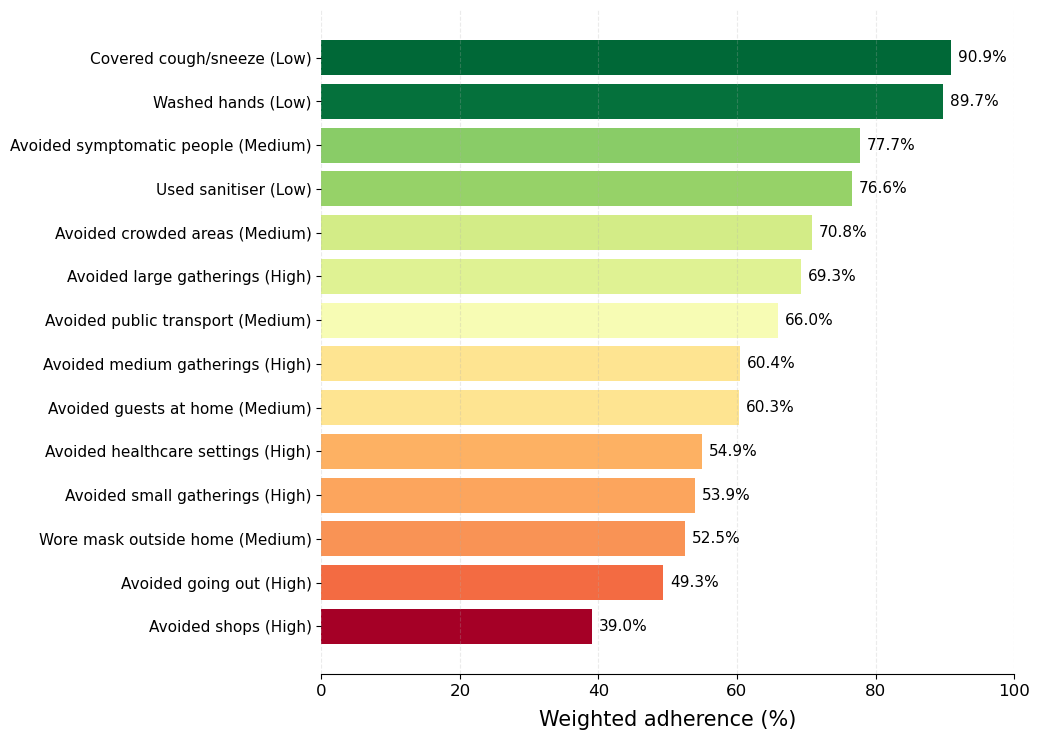

In [9]:
behaviour_summary = []

for col in behaviour_cols:
    binary_col = col + "_adherent"
    
    adherence_rate = weighted_mean(df[binary_col], df[weight_col]) * 100
    mean_score = weighted_mean(df[col], df[weight_col])
    
    behaviour_summary.append({
        "behaviour": col,
        "behaviour_label": graph_names[col],
        "cost_group": cost_group_map[col],
        "mean_score_1_to_5": mean_score,
        "adherence_rate_percent": adherence_rate
    })

behaviour_summary = pd.DataFrame(behaviour_summary)
behaviour_summary = behaviour_summary.sort_values("adherence_rate_percent", ascending=False)

display(behaviour_summary)



import matplotlib.cm as cm
import matplotlib.colors as mcolors

plot_data = behaviour_summary.copy()

# Add cost group to graph label
plot_data["plot_label"] = (
    plot_data["behaviour_label"] + " (" + plot_data["cost_group"] + ")"
)

# Green for high adherence, red for low adherence
norm = mcolors.Normalize(
    vmin=plot_data["adherence_rate_percent"].min(),
    vmax=plot_data["adherence_rate_percent"].max()
)

colors = cm.get_cmap("RdYlGn")(
    norm(plot_data["adherence_rate_percent"])
)

fig, ax = plt.subplots(figsize=(10.5, 7.5))

bars = ax.barh(
    plot_data["plot_label"],
    plot_data["adherence_rate_percent"],
    color=colors
)

ax.invert_yaxis()


ax.set_xlabel("Weighted adherence (%)", fontsize=15, labelpad=8)
ax.set_ylabel("")
ax.set_xlim(0, 100)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=11)

# Add percentage labels at the end of bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=11
    )

ax.grid(axis="x", linestyle="--", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig(output_dir / "01_overall_adherence_by_behaviour.png", dpi=300, bbox_inches="tight")
plt.show()

,cost_group,adherence_rate_percent
0,Low,85.670985
1,Medium,65.470070
2,High,54.490337


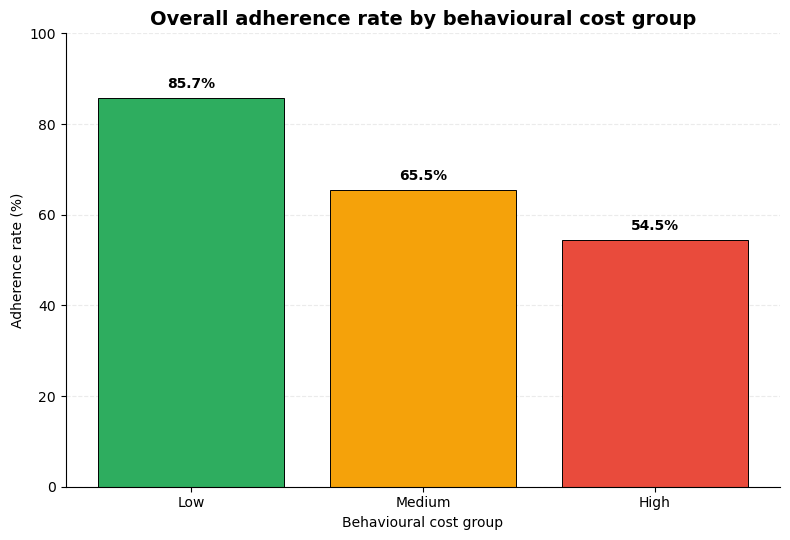

In [10]:
# Create respondent-level adherence rates for each behavioural cost group
# These are used only for EDA summaries and plots

df["low_adherence_rate"] = df[[col + "_adherent" for col in low_cost]].mean(axis=1) * 100
df["medium_adherence_rate"] = df[[col + "_adherent" for col in medium_cost]].mean(axis=1) * 100
df["high_adherence_rate"] = df[[col + "_adherent" for col in high_cost]].mean(axis=1) * 100

cost_summary = pd.DataFrame({
    "cost_group": ["Low", "Medium", "High"],
    "adherence_rate_percent": [
        weighted_mean(df["low_adherence_rate"], df[weight_col]),
        weighted_mean(df["medium_adherence_rate"], df[weight_col]),
        weighted_mean(df["high_adherence_rate"], df[weight_col])
    ]
})

display(cost_summary)
# Plot overall adherence by behavioural cost group

plot_data = cost_summary.copy()

cost_colors = {
    "Low": "#2EAD5F",      # green
    "Medium": "#F5A20A",   # orange
    "High": "#E94B3C"      # red
}

fig, ax = plt.subplots(figsize=(8, 5.5))

bars = ax.bar(
    plot_data["cost_group"],
    plot_data["adherence_rate_percent"],
    color=[cost_colors[group] for group in plot_data["cost_group"]],
    edgecolor="black",
    linewidth=0.7
)

ax.set_title(
    "Overall adherence rate by behavioural cost group",
    fontsize=14,
    weight="bold"
)

ax.set_xlabel("Behavioural cost group")
ax.set_ylabel("Adherence rate (%)")
ax.set_ylim(0, 100)

# Add percentage labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.5,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold"
    )

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

,week_num,low_adherence_rate,medium_adherence_rate,high_adherence_rate
0,1,86.154227,75.166297,80.920458
1,2,85.693976,74.432231,81.373366
2,3,85.647510,72.518497,79.163814
3,4,85.752066,75.044198,78.650324
4,5,85.809393,72.376454,77.352922


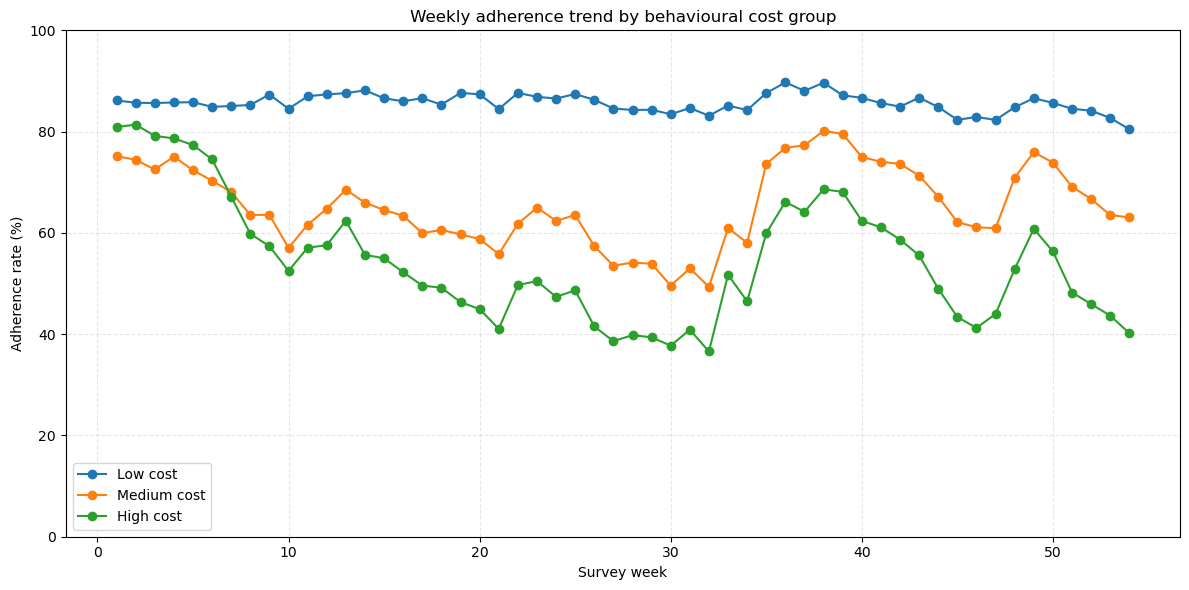

In [11]:
weekly_trend = []

for week in sorted(df["week_num"].dropna().unique()):
    temp = df[df["week_num"] == week]
    
    weekly_trend.append({
        "week_num": week,
        "low_adherence_rate": weighted_mean(temp["low_adherence_rate"], temp[weight_col]),
        "medium_adherence_rate": weighted_mean(temp["medium_adherence_rate"], temp[weight_col]),
        "high_adherence_rate": weighted_mean(temp["high_adherence_rate"], temp[weight_col])
    })

weekly_trend = pd.DataFrame(weekly_trend)

display(weekly_trend.head())

# weekly_trend.to_csv("EDA_weekly_cost_group_trend.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(weekly_trend["week_num"], weekly_trend["low_adherence_rate"], marker="o", label="Low cost")
ax.plot(weekly_trend["week_num"], weekly_trend["medium_adherence_rate"], marker="o", label="Medium cost")
ax.plot(weekly_trend["week_num"], weekly_trend["high_adherence_rate"], marker="o", label="High cost")

ax.set_title("Weekly adherence trend by behavioural cost group")
ax.set_xlabel("Survey week")
ax.set_ylabel("Adherence rate (%)")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

,week_block,block_end_week,low_adherence_rate,medium_adherence_rate,high_adherence_rate
0,1,6,85.654646,73.291940,78.644711
1,2,12,86.079769,63.095169,58.586711
2,3,18,86.708733,63.827463,54.012140
3,4,24,86.738646,60.560471,46.603886
4,5,30,85.045167,55.357929,40.980715
5,6,36,85.764139,62.031626,50.362070
6,7,42,87.014298,76.604074,63.830989
7,8,48,83.984967,65.603576,47.673740
8,9,54,84.003406,68.726577,49.270364


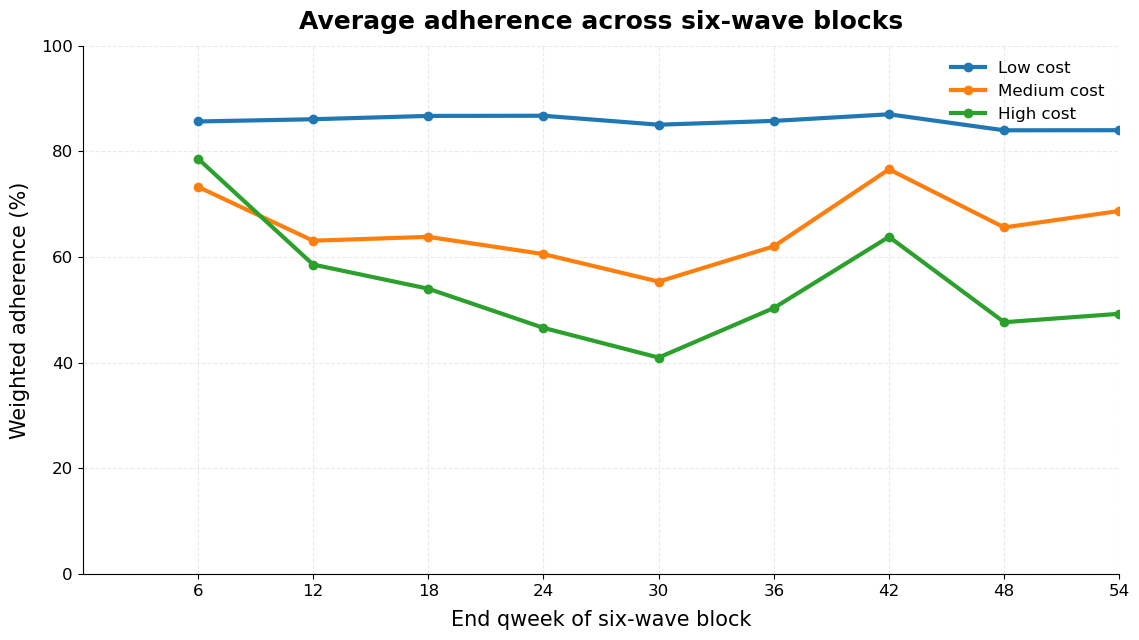

In [12]:
# Create equal 6-week blocks
# Each point represents the average adherence rate across a 6-week period

df["week_block"] = ((df["week_num"] - 1) // 6) + 1
df["block_end_week"] = df["week_block"] * 6

block_trend = []

for block in sorted(df["week_block"].dropna().unique()):
    temp = df[df["week_block"] == block]
    
    block_trend.append({
        "week_block": block,
        "block_end_week": block * 6,
        "low_adherence_rate": weighted_mean(temp["low_adherence_rate"], temp[weight_col]),
        "medium_adherence_rate": weighted_mean(temp["medium_adherence_rate"], temp[weight_col]),
        "high_adherence_rate": weighted_mean(temp["high_adherence_rate"], temp[weight_col])
    })

block_trend = pd.DataFrame(block_trend)

display(block_trend)

fig, ax = plt.subplots(figsize=(11.5, 6.5))

ax.plot(
    block_trend["block_end_week"],
    block_trend["low_adherence_rate"],
    marker="o",
    markersize=6,
    linewidth=3,
    label="Low cost"
)

ax.plot(
    block_trend["block_end_week"],
    block_trend["medium_adherence_rate"],
    marker="o",
    markersize=6,
    linewidth=3,
    label="Medium cost"
)

ax.plot(
    block_trend["block_end_week"],
    block_trend["high_adherence_rate"],
    marker="o",
    markersize=6,
    linewidth=3,
    label="High cost"
)

ax.set_title(
    "Average adherence across six-wave blocks",
    fontsize=18,
    weight="bold",
    pad=12
)

ax.set_xlabel("End qweek of six-wave block", fontsize=15, labelpad=8)
ax.set_ylabel("Weighted adherence (%)", fontsize=15, labelpad=8)

ax.set_xlim(0, 54)
ax.set_xticks([6, 12, 18, 24, 30, 36, 42, 48, 54])
ax.set_ylim(0, 100)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

ax.grid(True, linestyle="--", alpha=0.25)

ax.legend(
    frameon=False,
    fontsize=12,
    loc="upper right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(output_dir / "02_6week_cost_group_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# Compare adherence between the first and final 6-week periods

first_block = block_trend[block_trend["week_block"] == 1].iloc[0]
final_block = block_trend[block_trend["week_block"] == 9].iloc[0]

change_summary = pd.DataFrame({
    "cost_group": ["Low", "Medium", "High"],
    "weeks_1_to_6": [
        first_block["low_adherence_rate"],
        first_block["medium_adherence_rate"],
        first_block["high_adherence_rate"]
    ],
    "weeks_49_to_54": [
        final_block["low_adherence_rate"],
        final_block["medium_adherence_rate"],
        final_block["high_adherence_rate"]
    ]
})

change_summary["change_percentage_points"] = (
    change_summary["weeks_49_to_54"] -
    change_summary["weeks_1_to_6"]
)

change_summary = change_summary.round(1)

display(change_summary)

,cost_group,weeks_1_to_6,weeks_49_to_54,change_percentage_points
0,Low,85.7,84.0,-1.7
1,Medium,73.3,68.7,-4.6
2,High,78.6,49.3,-29.4


,week_block,week_block_label,wore_mask_outside_home,avoided_contact_with_symptomatic_people,avoided_crowded_areas,avoided_public_transport,avoided_having_guests_at_home
0,1,qweeks 1–6,24.6,85.2,88.3,82.6,85.7
1,2,qweeks 7–12,24.3,78.1,77.6,71.4,64.0
2,3,qweeks 13–18,47.7,74.1,72.7,65.4,59.2
3,4,qweeks 19–24,48.3,74.7,66.8,61.8,51.2
4,5,qweeks 25–30,43.5,72.2,59.0,55.1,47.0
5,6,qweeks 31–36,52.5,76.0,64.7,61.1,55.8
6,7,qweeks 37–42,78.3,83.0,76.6,72.9,72.1
7,8,qweeks 43–48,73.0,76.5,64.6,61.5,52.4
8,9,qweeks 49–54,80.6,79.1,66.8,61.7,53.9


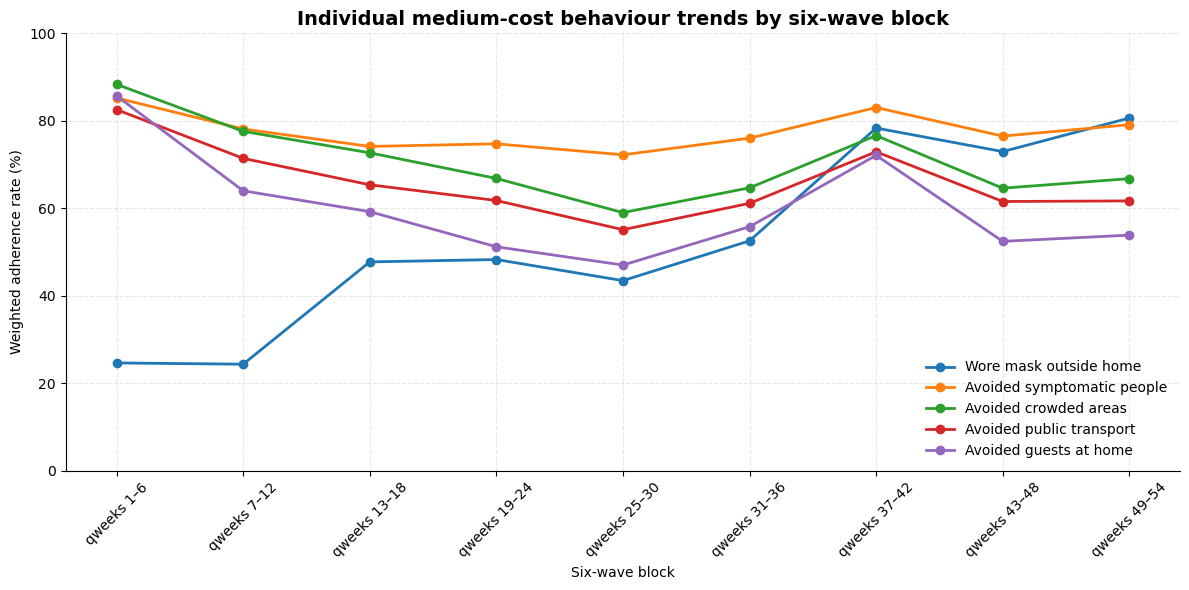

,week_block,week_block_label,avoided_small_social_gatherings,avoided_medium_social_gatherings,avoided_large_social_gatherings,avoided_going_out_in_general,avoided_going_to_shops,avoided_going_to_healthcare_settings
0,1,qweeks 1–6,84.0,89.7,91.9,75.7,58.8,71.7
1,2,qweeks 7–12,56.6,66.5,77.7,53.5,42.4,54.9
2,3,qweeks 13–18,52.8,60.8,71.7,49.7,38.4,50.6
3,4,qweeks 19–24,44.0,51.4,62.8,40.5,31.1,49.8
4,5,qweeks 25–30,38.9,44.6,55.0,34.3,26.7,46.3
5,6,qweeks 31–36,49.5,55.3,62.8,45.4,36.4,52.7
6,7,qweeks 37–42,66.7,71.4,77.5,57.4,48.1,61.9
7,8,qweeks 43–48,45.7,51.4,60.4,42.4,34.4,51.9
8,9,qweeks 49–54,46.7,52.4,63.0,44.6,34.4,54.5


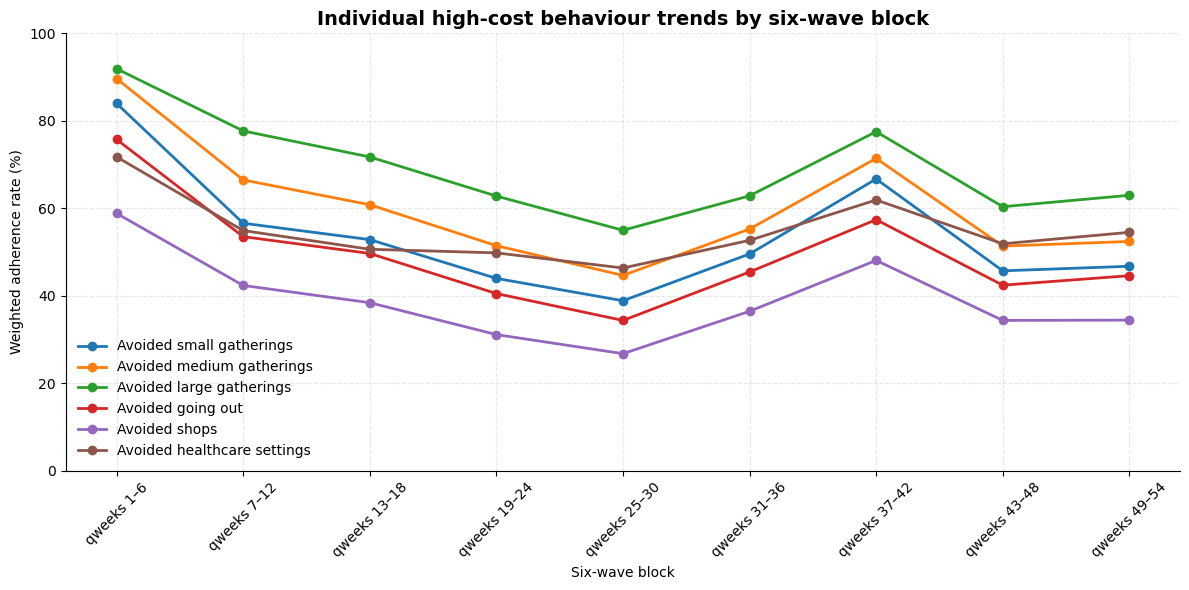

,behaviour,cost_group,weeks_31_36_pct,weeks_37_42_pct,change_pp
3,Wore mask outside home,Medium,52.5,78.3,25.8
8,Avoided small gatherings,High,49.5,66.7,17.2
7,Avoided guests at home,Medium,55.8,72.1,16.3
9,Avoided medium gatherings,High,55.3,71.4,16.2
10,Avoided large gatherings,High,62.8,77.5,14.7
11,Avoided going out,High,45.4,57.4,12.0
5,Avoided crowded areas,Medium,64.7,76.6,11.9
6,Avoided public transport,Medium,61.1,72.9,11.8
12,Avoided shops,High,36.4,48.1,11.6
13,Avoided healthcare settings,High,52.7,61.9,9.2


Saved: ..\graphs and tables\05_behaviour_change_surge.csv


In [14]:
# Individual behaviour trends by 6-week block
# This is mainly for EDA checking, not necessarily for the Beamer slides.

block_labels = {
    int(block): f"qweeks {(int(block) - 1) * 6 + 1}–{int(block) * 6}"
    for block in sorted(df["week_block"].dropna().unique())
}

def behaviour_block_trend(behaviour_list, group_name):
    rows = []
    
    for block in sorted(df["week_block"].dropna().unique()):
        block = int(block)
        temp = df[df["week_block"] == block]
        
        row = {
            "week_block": block,
            "week_block_label": block_labels[block]
        }
        
        for col in behaviour_list:
            binary_col = col + "_adherent"
            row[col] = weighted_mean(temp[binary_col], temp[weight_col]) * 100
        
        rows.append(row)
    
    trend_df = pd.DataFrame(rows)
    
    display(trend_df.round(1))
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for col in behaviour_list:
        ax.plot(
            trend_df["week_block_label"],
            trend_df[col],
            marker="o",
            linewidth=2,
            label=graph_names[col]
        )
    
    ax.set_title(
    f"Individual {group_name.lower()}-cost behaviour trends by six-wave block",
    fontsize=14,
    weight="bold"
)
    
    ax.set_xlabel("Six-wave block")
    ax.set_ylabel("Weighted adherence rate (%)")
    ax.set_ylim(0, 100)
    
    ax.legend(loc="best", frameon=False)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.tick_params(axis="x", rotation=45)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(
    output_dir / f"04_{group_name.lower()}_behaviour_trend.png",
    dpi=300,
    bbox_inches="tight"
    )
    plt.show()
    
    return trend_df


medium_behaviour_block_trend = behaviour_block_trend(medium_cost, "Medium")
high_behaviour_block_trend = behaviour_block_trend(high_cost, "High")

# Behaviour-level change from Weeks 31-36 to Weeks 37-42

surge_start_block = 6   # Weeks 31-36
surge_end_block = 7     # Weeks 37-42

behaviour_groups = []

for col in low_cost:
    behaviour_groups.append((col, "Low"))

for col in medium_cost:
    behaviour_groups.append((col, "Medium"))

for col in high_cost:
    behaviour_groups.append((col, "High"))

rows = []

for col, cost_group in behaviour_groups:
    binary_col = col + "_adherent"
    
    start_data = df[df["week_block"] == surge_start_block]
    end_data = df[df["week_block"] == surge_end_block]
    
    start_pct = weighted_mean(start_data[binary_col], start_data[weight_col]) * 100
    end_pct = weighted_mean(end_data[binary_col], end_data[weight_col]) * 100
    
    rows.append({
        "behaviour": graph_names[col],
        "cost_group": cost_group,
        "weeks_31_36_pct": start_pct,
        "weeks_37_42_pct": end_pct,
        "change_pp": end_pct - start_pct
    })

surge_summary = pd.DataFrame(rows)

surge_summary = surge_summary.sort_values("change_pp", ascending=False)

display(surge_summary.round(1))

surge_summary.to_csv(
    output_dir / "05_behaviour_change_surge.csv",
    index=False
)

print("Saved:", output_dir / "05_behaviour_change_surge.csv")

,behaviour,cost_group,weeks_31_to_36,weeks_37_to_42,change_pp
3,Wore mask outside home,Medium,52.5,78.3,25.8
8,Avoided small gatherings,High,49.5,66.7,17.2
7,Avoided guests at home,Medium,55.8,72.1,16.3
9,Avoided medium gatherings,High,55.3,71.4,16.2
10,Avoided large gatherings,High,62.8,77.5,14.7
11,Avoided going out,High,45.4,57.4,12.0
5,Avoided crowded areas,Medium,64.7,76.6,11.9
6,Avoided public transport,Medium,61.1,72.9,11.8
12,Avoided shops,High,36.4,48.1,11.6
13,Avoided healthcare settings,High,52.7,61.9,9.2


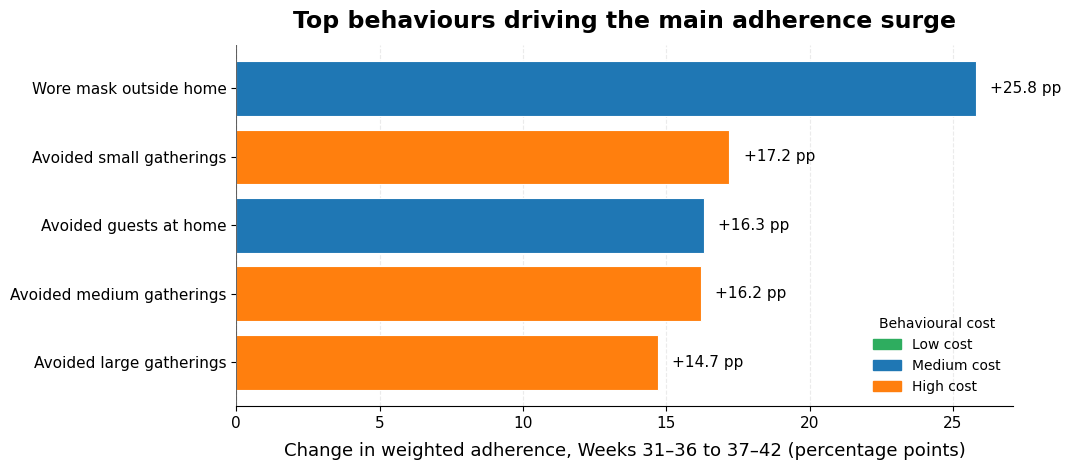

In [15]:
# Behaviour-level surge graph
# Computes ALL 14 behaviours, then saves:
# 1) all 14 behaviour surge graph for EDA
# 2) top 5 behaviour surge graph for Slide 10

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Use same output folder as your EDA notebook
output_dir = Path("../graphs and tables")
output_dir.mkdir(parents=True, exist_ok=True)

# Main surge blocks
start_block = 6   # Weeks 31–36
end_block = 7     # Weeks 37–42

start_data = df[df["week_block"] == start_block]
end_data = df[df["week_block"] == end_block]

# Use ALL 14 behaviours
all_behaviours = low_cost + medium_cost + high_cost

surge_rows = []

for col in all_behaviours:
    binary_col = col + "_adherent"
    
    before_rate = weighted_mean(start_data[binary_col], start_data[weight_col]) * 100
    after_rate = weighted_mean(end_data[binary_col], end_data[weight_col]) * 100
    
    surge_rows.append({
        "behaviour": graph_names[col],
        "cost_group": cost_group_map[col],
        "weeks_31_to_36": before_rate,
        "weeks_37_to_42": after_rate,
        "change_pp": after_rate - before_rate
    })

surge_summary_all = pd.DataFrame(surge_rows)
surge_summary_all = surge_summary_all.sort_values("change_pp", ascending=False)
surge_summary_all = surge_summary_all.round(1)

display(surge_summary_all)

# Save table too
surge_summary_all.to_csv(
    output_dir / "05_behaviour_surge_all14.csv",
    index=False
)




# Function to plot ranked surge graph
def plot_behaviour_surge(plot_data, filename, title, height=6.5):
    plot_data = plot_data.copy()
    
    # Sort ascending for horizontal bar plot so largest appears at top
    plot_data = plot_data.sort_values("change_pp", ascending=True)
    
    cost_colours = {
        "Low": "#2EAD5F",
        "Medium": "#1F77B4",
        "High": "#FF7F0E"
    }
    
    bar_colours = plot_data["cost_group"].map(cost_colours)
    
    fig, ax = plt.subplots(figsize=(10.8, height))
    
    bars = ax.barh(
        plot_data["behaviour"],
        plot_data["change_pp"],
        color=bar_colours,
        edgecolor="white",
        linewidth=0.8
    )
    
    # Vertical zero line
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        
        if width >= 0:
            ax.text(
                width + 0.5,
                y,
                f"+{width:.1f} pp",
                va="center",
                fontsize=11
            )
        else:
            ax.text(
                width - 0.5,
                y,
                f"{width:.1f} pp",
                va="center",
                ha="right",
                fontsize=11
            )
    
    ax.set_title(
        title,
        fontsize=17,
        weight="bold",
        pad=12
    )
    
    ax.set_xlabel(
        "Change in weighted adherence, Weeks 31–36 to 37–42 (percentage points)",
        fontsize=13,
        labelpad=8
    )
    
    ax.set_ylabel("")
    
    ax.tick_params(axis="y", labelsize=11)
    ax.tick_params(axis="x", labelsize=11)
    
    ax.grid(axis="x", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    
    # Legend
    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=cost_colours["Low"], label="Low cost"),
        plt.Rectangle((0, 0), 1, 1, color=cost_colours["Medium"], label="Medium cost"),
        plt.Rectangle((0, 0), 1, 1, color=cost_colours["High"], label="High cost")
    ]
    
    ax.legend(
        handles=legend_handles,
        title="Behavioural cost",
        frameon=False,
        loc="lower right",
        fontsize=10,
        title_fontsize=10
    )
    
    plt.tight_layout()
    plt.savefig(
        output_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )
    
    plt.show()
    




# Top 5 behaviours only
surge_summary_top5 = surge_summary_all.head(5)

plot_behaviour_surge(
    plot_data=surge_summary_top5,
    filename="05_behaviour_surge_top5.png",
    title="Top behaviours driving the main adherence surge",
    height=4.8
)

In [16]:
# State-level changes during the main surge:
# Weeks 31–36 to Weeks 37–42

start_block = 6   # Weeks 31–36
end_block = 7     # Weeks 37–42

state_surge_rows = []

for state in sorted(df["state"].dropna().unique()):
    start_data = df[(df["week_block"] == start_block) & (df["state"] == state)]
    end_data = df[(df["week_block"] == end_block) & (df["state"] == state)]
    
    if len(start_data) == 0 or len(end_data) == 0:
        continue
    
    state_surge_rows.append({
        "state": state,
        "n_responses_31_to_36": len(start_data),
        "n_responses_37_to_42": len(end_data),
        "medium_31_to_36": weighted_mean(start_data["medium_adherence_rate"], start_data[weight_col]),
        "medium_37_to_42": weighted_mean(end_data["medium_adherence_rate"], end_data[weight_col]),
        "high_31_to_36": weighted_mean(start_data["high_adherence_rate"], start_data[weight_col]),
        "high_37_to_42": weighted_mean(end_data["high_adherence_rate"], end_data[weight_col])
    })

state_surge_summary = pd.DataFrame(state_surge_rows)

state_surge_summary["medium_change"] = (
    state_surge_summary["medium_37_to_42"] -
    state_surge_summary["medium_31_to_36"]
)

state_surge_summary["high_change"] = (
    state_surge_summary["high_37_to_42"] -
    state_surge_summary["high_31_to_36"]
)

state_surge_summary = state_surge_summary.round(1)

display(
    state_surge_summary[
        [
            "state",
            "n_responses_31_to_36",
            "n_responses_37_to_42",
            "medium_31_to_36",
            "medium_37_to_42",
            "medium_change",
            "high_31_to_36",
            "high_37_to_42",
            "high_change"
        ]
    ].sort_values("medium_change", ascending=False)
)



,state,n_responses_31_to_36,n_responses_37_to_42,medium_31_to_36,medium_37_to_42,medium_change,high_31_to_36,high_37_to_42,high_change
0,Australian Capital Territory,87,99,54.6,84.5,29.9,39.0,71.4,32.3
1,New South Wales,1802,1864,66.6,89.3,22.7,56.0,79.3,23.3
4,South Australia,614,596,50.3,71.5,21.2,41.1,48.6,7.6
6,Victoria,1535,1555,70.6,86.8,16.2,55.6,75.1,19.5
3,Queensland,1197,1187,53.9,66.9,13.0,43.9,49.5,5.5
2,Northern Territory,46,41,47.6,54.7,7.1,31.2,44.7,13.5
5,Tasmania,121,123,37.3,42.1,4.9,27.9,31.9,4.0
7,Western Australia,593,565,57.6,41.4,-16.2,46.8,32.4,-14.4


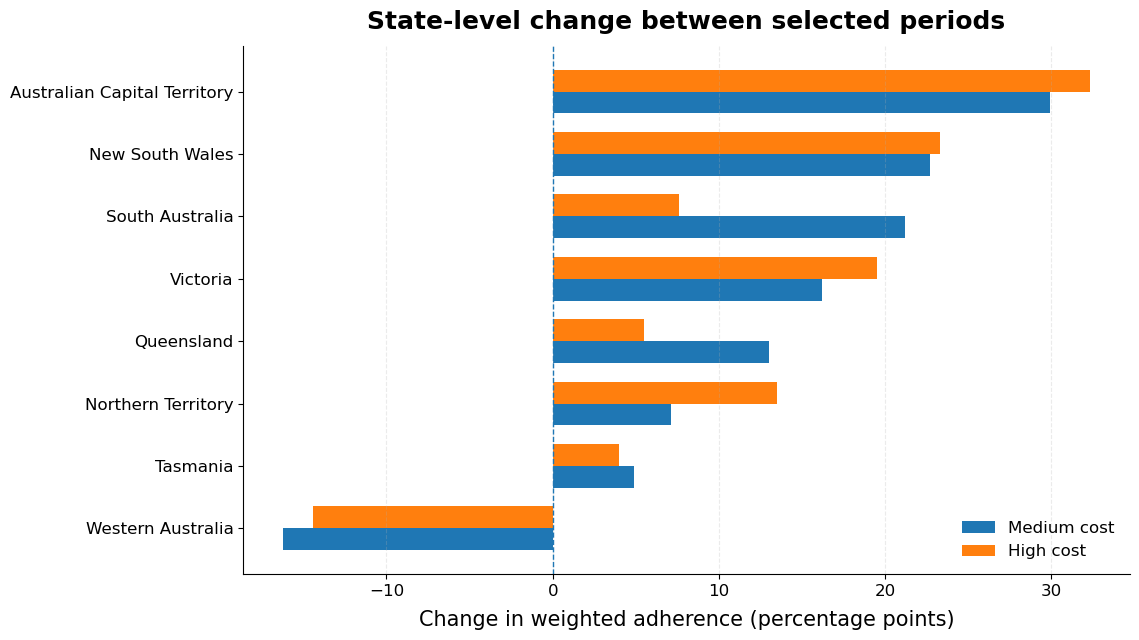

In [17]:
# Save state-level surge graph

plot_data = state_surge_summary.sort_values("medium_change", ascending=True)

fig, ax = plt.subplots(figsize=(11.5, 6.5))

y_pos = np.arange(len(plot_data))
bar_height = 0.35

ax.barh(
    y_pos - bar_height / 2,
    plot_data["medium_change"],
    height=bar_height,
    label="Medium cost"
)

ax.barh(
    y_pos + bar_height / 2,
    plot_data["high_change"],
    height=bar_height,
    label="High cost"
)

ax.axvline(0, linestyle="--", linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_data["state"], fontsize=12)

ax.set_title(
    "State-level change between selected periods",
    fontsize=18,
    weight="bold",
    pad=12
)

ax.set_xlabel(
    "Change in weighted adherence (percentage points)",
    fontsize=15,
    labelpad=8
)

ax.set_ylabel("")

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

ax.grid(axis="x", linestyle="--", alpha=0.25)

ax.legend(
    frameon=False,
    fontsize=12,
    loc="lower right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(output_dir / "03_state_surge_change.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
# Save numerical tables used in the report and appendix

behaviour_summary.to_csv(
    output_dir / "01_overall_adherence_by_behaviour.csv",
    index=False
)

block_trend.to_csv(
    output_dir / "02_cost_group_trend_by_six_wave_block.csv",
    index=False
)

medium_behaviour_block_trend.to_csv(
    output_dir / "04_medium_behaviour_trend.csv",
    index=False
)

high_behaviour_block_trend.to_csv(
    output_dir / "04_high_behaviour_trend.csv",
    index=False
)

state_surge_summary.to_csv(
    output_dir / "03_state_surge_summary.csv",
    index=False
)

print("Report and appendix tables saved.")

Report and appendix tables saved.
